In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

In [ ]:
uploaded = files.upload()

data_file = next(iter(uploaded))
print("Uploaded file:", data_file)

Saving wine.data to wine.data
Uploaded file: wine.data


In [ ]:
columns = [
    "Class", "Alcohol", "Malic_Acid", "Ash", "Alcalinity_of_Ash",
    "Magnesium", "Total_Phenols", "Flavanoids", "Nonflavanoid_Phenols",
    "Proanthocyanins", "Color_Intensity", "Hue",
    "OD280_OD315", "Proline"
]

df = pd.read_csv(
    io.BytesIO(uploaded[data_file]),
    header=None,
    names=columns
)

print("Dataset shape:", df.shape)
print("\nClass counts:")
print(df["Class"].value_counts().sort_index())

df.head()

Dataset shape: (178, 14)

Class counts:
Class
1    59
2    71
3    48
Name: count, dtype: int64


,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
df.describe()

Missing values:
Class                   0
Alcohol                 0
Malic_Acid              0
Ash                     0
Alcalinity_of_Ash       0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64

Statistical summary:


,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


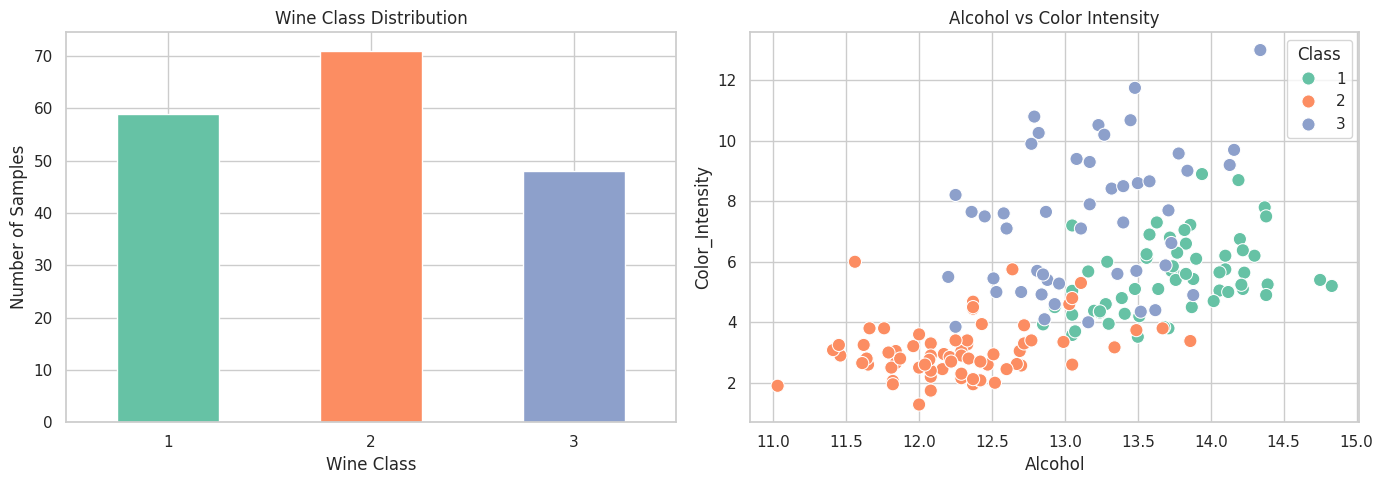

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Class"].value_counts().sort_index().plot(
    kind="bar",
    color=["#66c2a5", "#fc8d62", "#8da0cb"],
    ax=axes[0]
)
axes[0].set_title("Wine Class Distribution")
axes[0].set_xlabel("Wine Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=0)

sns.scatterplot(
    data=df,
    x="Alcohol",
    y="Color_Intensity",
    hue="Class",
    palette="Set2",
    s=90,
    ax=axes[1]
)
axes[1].set_title("Alcohol vs Color Intensity")

plt.tight_layout()
plt.show()

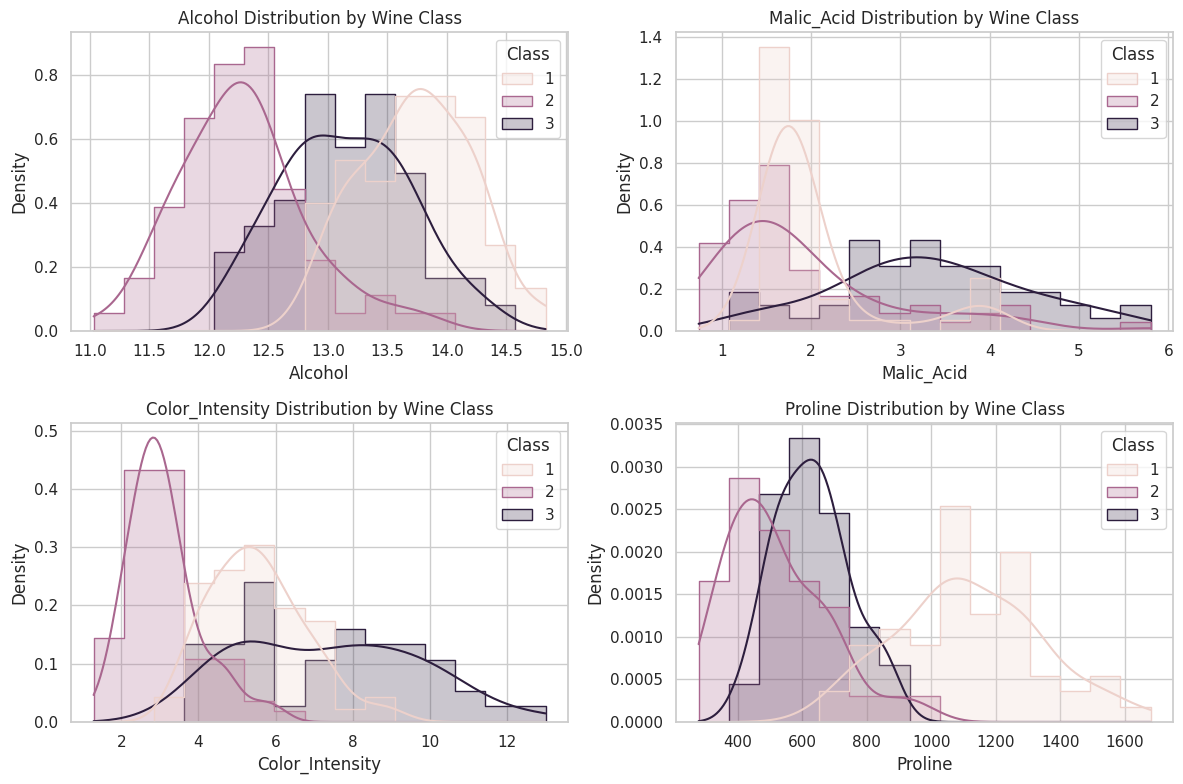

In [ ]:
features_to_plot = ["Alcohol", "Malic_Acid", "Color_Intensity", "Proline"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        kde=True,
        bins=15,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution by Wine Class")

plt.tight_layout()
plt.show()

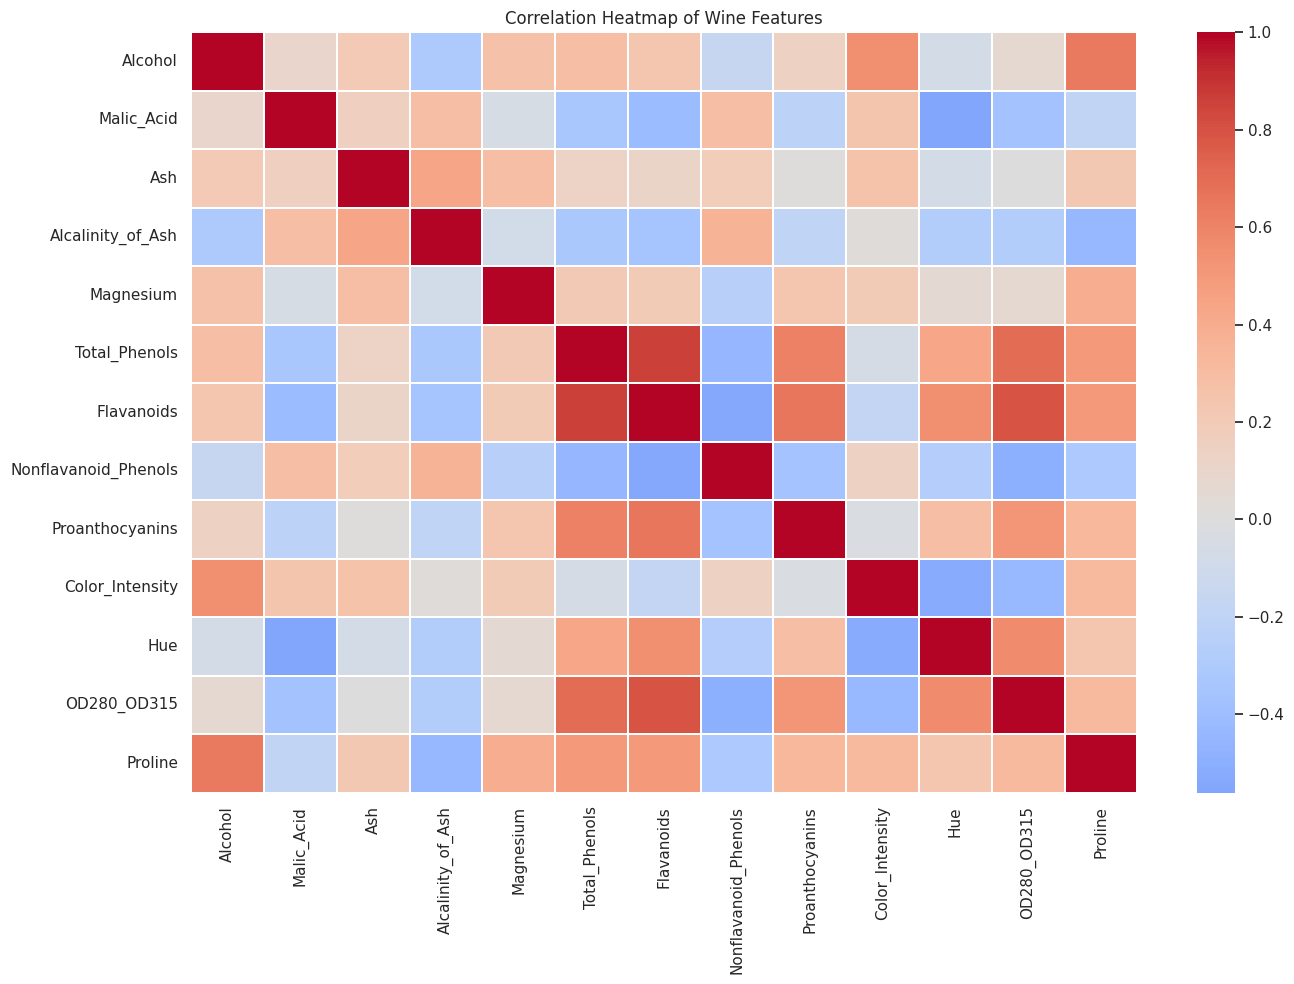

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.drop(columns="Class").corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()
plt.show()

## Bayes Rule

\[
P(C \mid X) = \frac{P(X \mid C)P(C)}{P(X)}
\]

Where:

- \(P(C \mid X)\) is the probability of class \(C\) after observing data \(X\).
- \(P(X \mid C)\) is the probability of observing data \(X\) if it belongs to class \(C\).
- \(P(C)\) is the prior probability of class \(C\).
- \(P(X)\) is the probability of observing the data.

Naive Bayes assumes that features are independent given the class:

\[
P(C \mid X_1, X_2, ..., X_n) \propto P(C)\prod_{i=1}^{n}P(X_i \mid C)
\]

Gaussian Naive Bayes is used because the Wine dataset contains continuous numerical features.

In [ ]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training samples: 133
Testing samples: 45
Accuracy: 97.78 %

Classification Report:

              precision    recall  f1-score   support

           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        18
           3       1.00      1.00      1.00        12

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



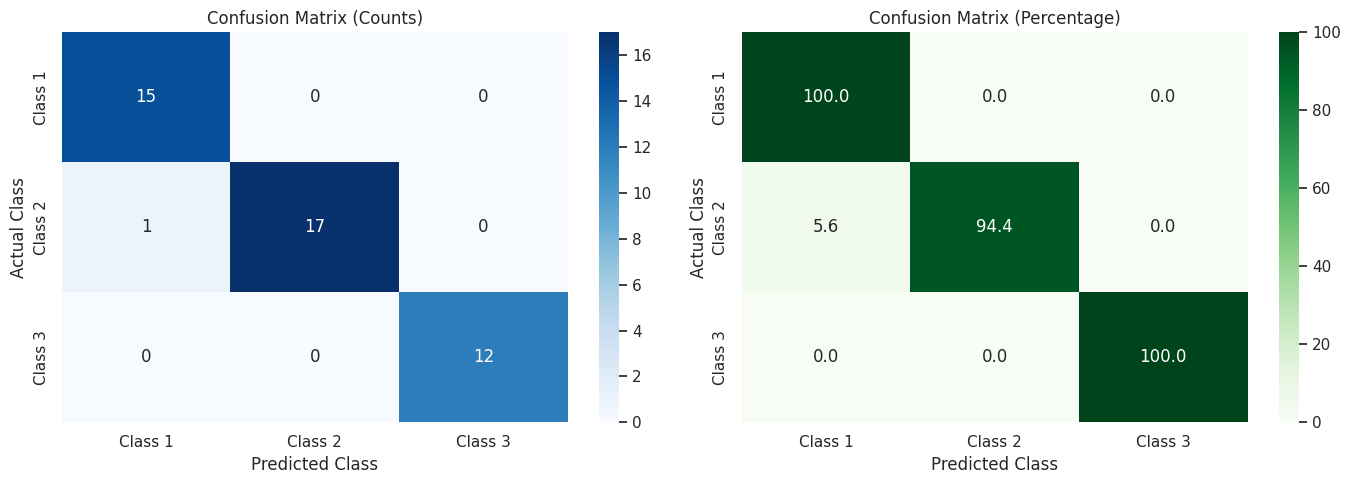

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
cm_percentage = cm / cm.sum(axis=1, keepdims=True) * 100

labels = ["Class 1", "Class 2", "Class 3"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(
    cm_percentage,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix (Percentage)")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=[1, 2, 3],
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": labels,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

metrics_df

,Class,Precision,Recall,F1-score
0,Class 1,0.9375,1.000000,0.967742
1,Class 2,1.0000,0.944444,0.971429
2,Class 3,1.0000,1.000000,1.000000


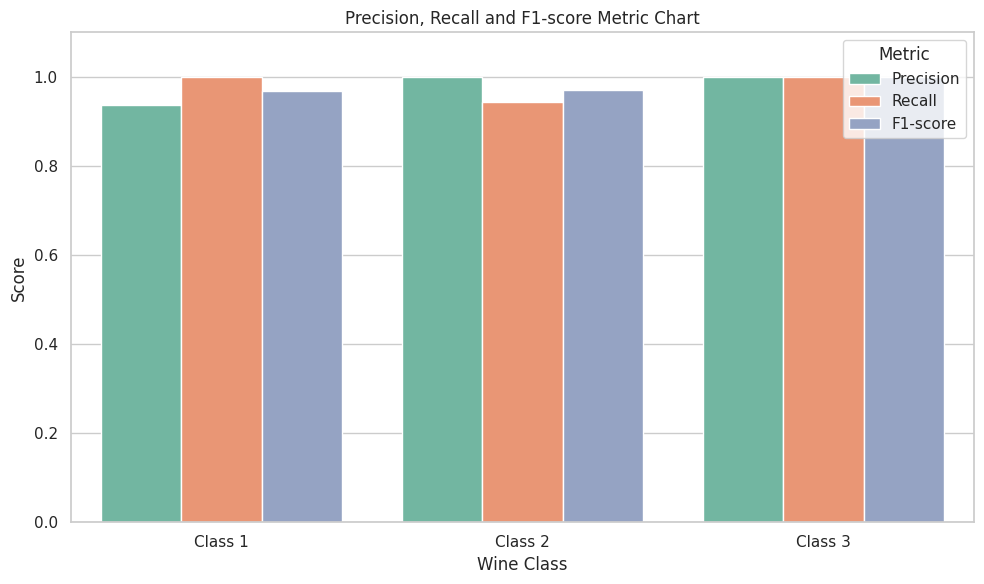

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=[1, 2, 3],
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": ["Class 1", "Class 2", "Class 3"],
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
})

plot_df = metrics_df.melt(
    id_vars="Class",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="Class",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.ylim(0, 1.1)
plt.title("Precision, Recall and F1-score Metric Chart")
plt.xlabel("Wine Class")
plt.ylabel("Score")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()